In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120,
})
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
sns.set_palette(COLORS)

In [3]:
df = pd.read_csv('C:\\Users\\tawal\\Downloads\\creditworthiness-prediction\\german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [4]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"\nDataset info:")
print(df.info())
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive statistics:\n{df.describe().round(2)}")

Dataset shape: (1000, 9)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB
None

Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

Descriptive statistics:
           Age      Jo

In [5]:
# Explore categorical variables
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

print("\n" + "=" * 50)
print("JOB DISTRIBUTION")
print("=" * 50)
job_map = {0: 'Unskilled (non-res)', 1: 'Unskilled (res)', 2: 'Skilled', 3: 'Highly skilled'}
for code, label in job_map.items():
    count = (df['Job'] == code).sum()
    print(f"  {code} ({label}): {count}")


--- Sex ---
Sex
male      690
female    310
Name: count, dtype: int64

--- Housing ---
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

--- Saving accounts ---
Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

--- Checking account ---
Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

--- Purpose ---
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

JOB DISTRIBUTION
  0 (Unskilled (non-res)): 22
  1 (Unskilled (res)): 200
  2 (Skilled): 630
  3 (Highly skilled): 148


In [6]:
# --- Engineer the target (creditworthiness) ---

np.random.seed(42)  # Fixed seed for reproducibility

# Map categorical savings/checking to numeric scores
savings_map = {'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3, np.nan: 1}
checking_map = {'little': 0, 'moderate': 1, 'rich': 2, np.nan: 1}

# Map housing to risk (own=safer, rent=riskier)
housing_map = {'own': 2, 'free': 1, 'rent': 0}

# Compute a creditworthiness score
# Higher score = better creditworthiness (lower risk)
score = (
    # Positive factors
    - np.log1p(df['Credit amount']) * 0.3               # Lower loan = better
    - df['Duration'] * 0.01                              # Shorter duration = better
    + df['Saving accounts'].map(savings_map).fillna(1) * 2  # More savings = better
    + df['Checking account'].map(checking_map).fillna(1) * 2  # More checking = better
    + df['Housing'].map(housing_map).fillna(1) * 1.5     # Own housing = better
    + df['Job'] * 1.5                                   # Higher skill = better
    + np.log1p(df['Age']) * 0.5                          # Older = slightly better
    + np.random.normal(0, 2, len(df))                    # Random noise
)

# Normalize to [0, 1]
score_min, score_max = score.min(), score.max()
prob_good = (score - score_min) / (score_max - score_min)

# Threshold: 60th percentile -> Good credit (1), rest -> Bad credit (0)
df['creditworthiness'] = (prob_good > 0.6).astype(int)

# Class distribution
class_counts = df['creditworthiness'].value_counts()
class_pcts = df['creditworthiness'].value_counts(normalize=True) * 100
print("Target Distribution:")
for label, count, pct in zip(['Bad Credit (0)', 'Good Credit (1)'], class_counts, class_pcts):
    print(f"  {label:20s}: {count:4d}  ({pct:.2f}%)")

print(f"\nDataset now has {df.shape[1]} columns including the target.")
df.head()

Target Distribution:
  Bad Credit (0)      :  907  (90.70%)
  Good Credit (1)     :   93  (9.30%)

Dataset now has 10 columns including the target.


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,creditworthiness
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,0


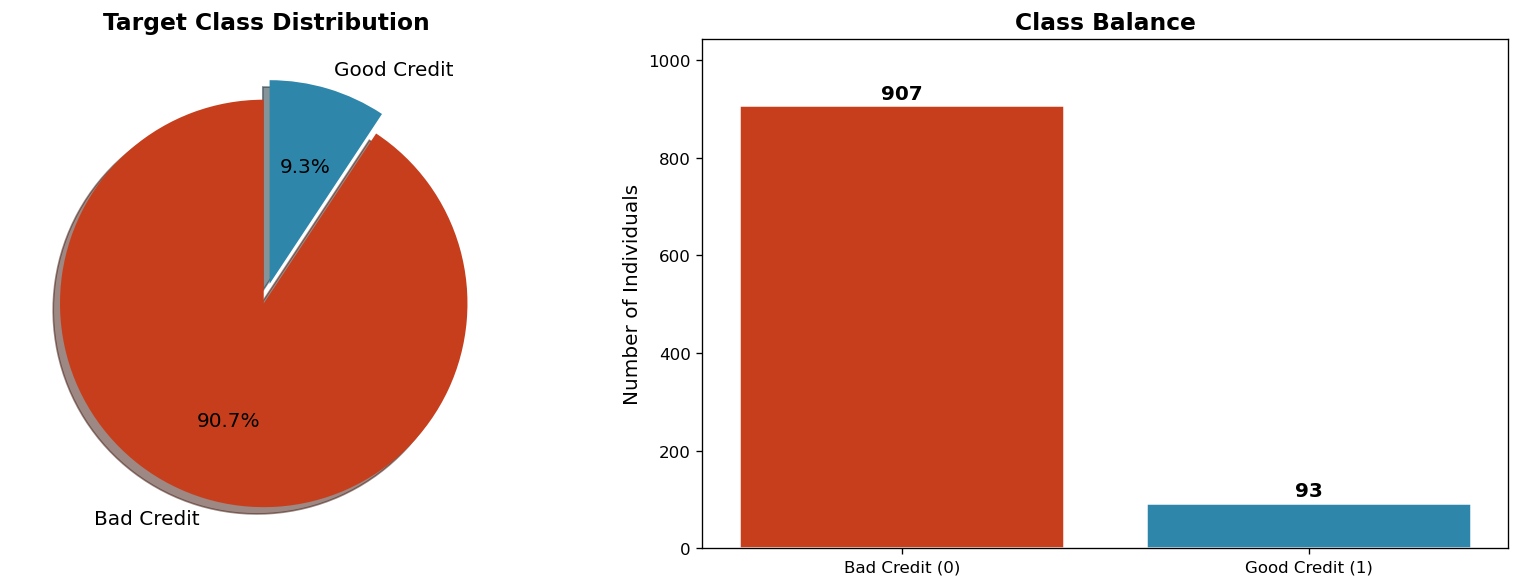

In [7]:
# Figure 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = ['#C73E1D', '#2E86AB']
axes[0].pie(class_counts, labels=['Bad Credit', 'Good Credit'],
            autopct='%1.1f%%', startangle=90, colors=colors_pie,
            explode=(0.05, 0.05), shadow=True, textprops={'fontsize': 12})
axes[0].set_title('Target Class Distribution', fontweight='bold')

bars = axes[1].bar(['Bad Credit (0)', 'Good Credit (1)'], class_counts,
                   color=colors_pie, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, class_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Individuals')
axes[1].set_title('Class Balance', fontweight='bold')
axes[1].set_ylim(0, class_counts.max() * 1.15)

plt.tight_layout()
plt.show()

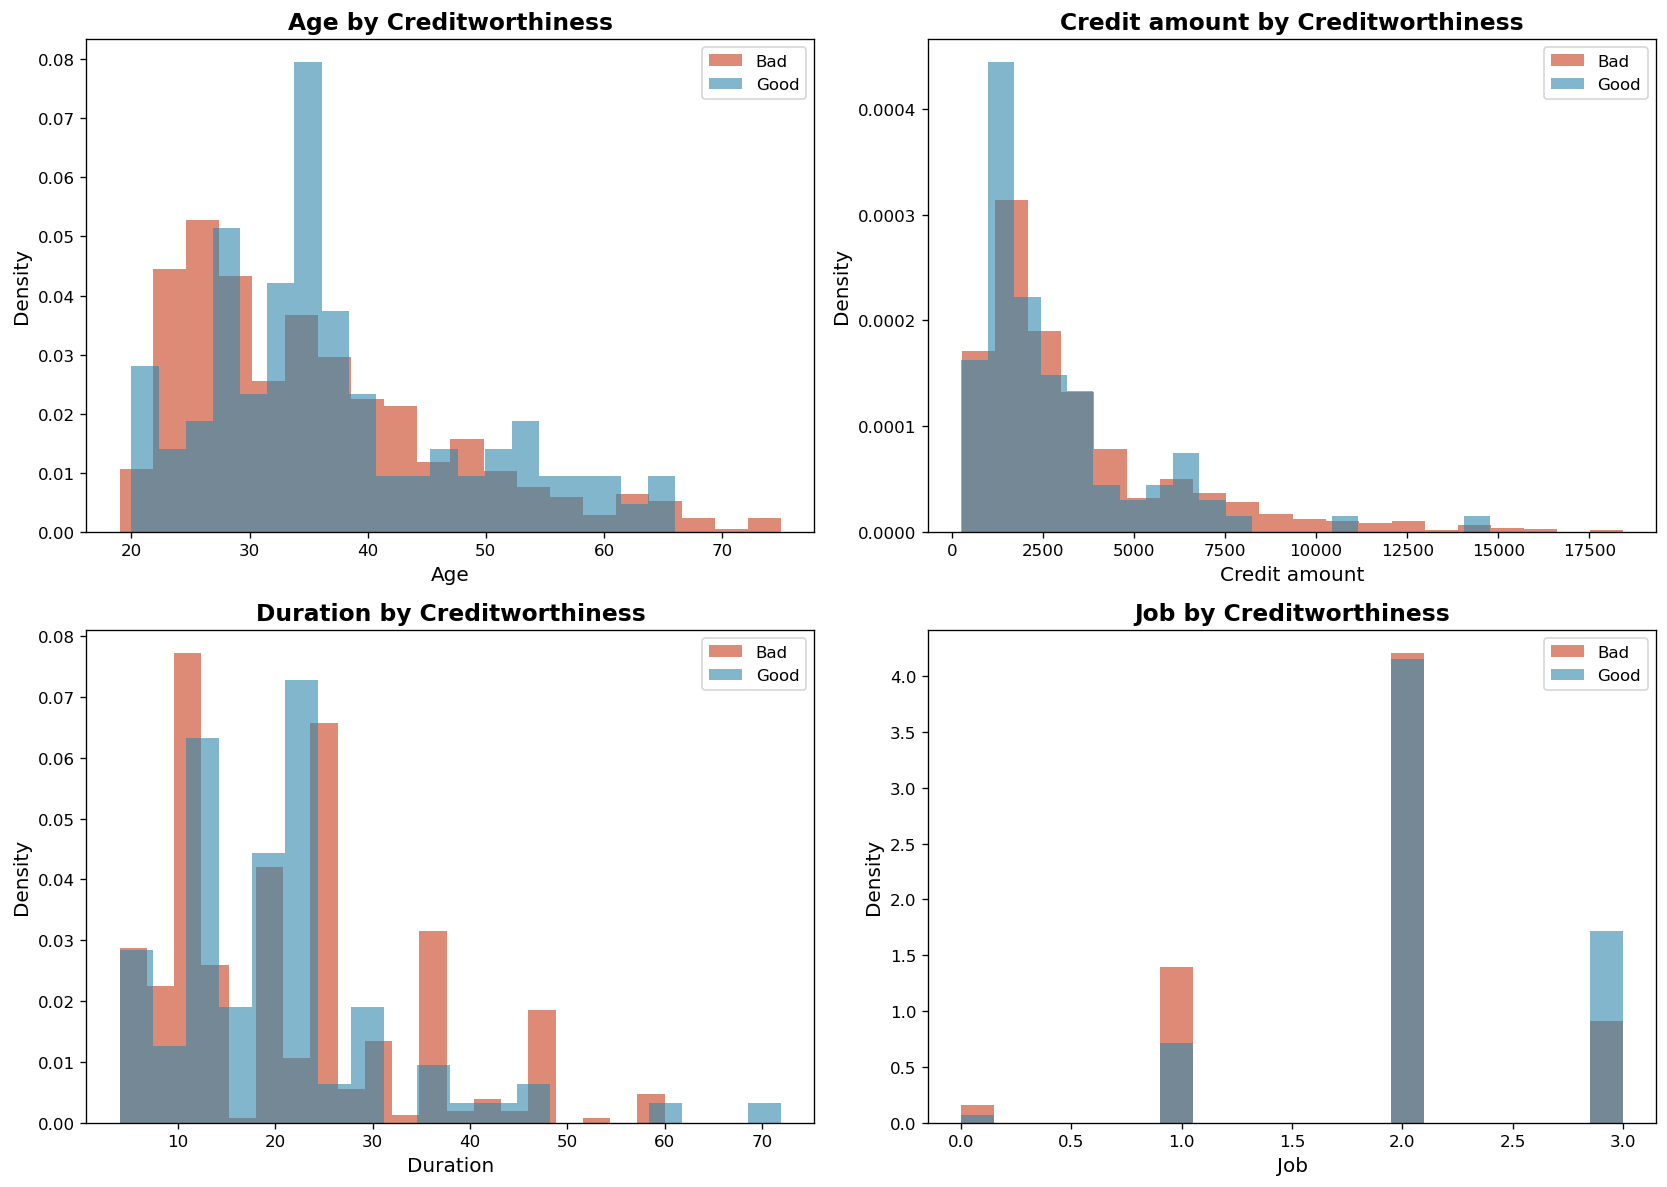

In [8]:
# Figure 2: Numeric Feature Distributions by Class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

numeric_cols = ['Age', 'Credit amount', 'Duration', 'Job']
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 2, idx % 2]
    for cls, color, label in zip([0, 1], ['#C73E1D', '#2E86AB'], ['Bad', 'Good']):
        subset = df[df['creditworthiness'] == cls][col]
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f'{col} by Creditworthiness', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

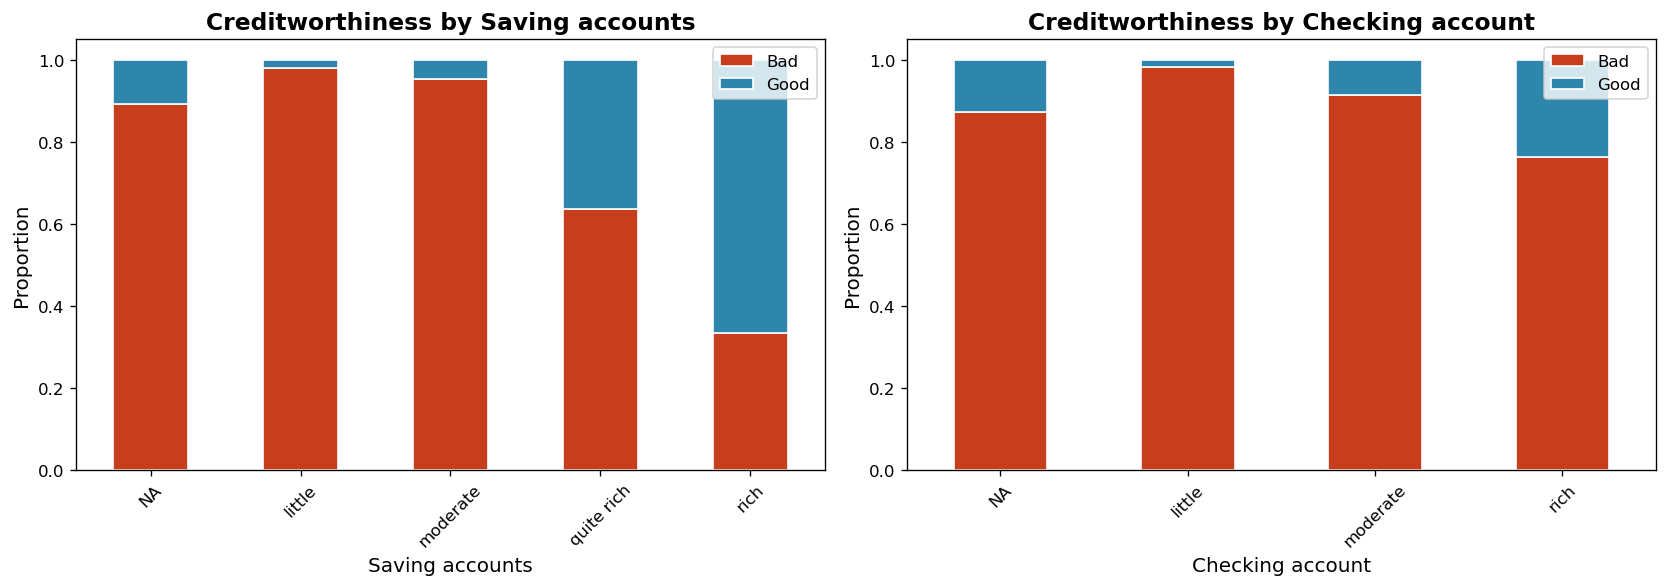

In [9]:
# Figure 3: Categorical Features vs Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(['Saving accounts', 'Checking account']):
    crosstab = pd.crosstab(df[col].fillna('NA'), df['creditworthiness'], normalize='index')
    crosstab.plot(kind='bar', ax=axes[idx], stacked=True,
                  color=['#C73E1D', '#2E86AB'], edgecolor='white')
    axes[idx].set_title(f'Creditworthiness by {col}', fontweight='bold')
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(['Bad', 'Good'])
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

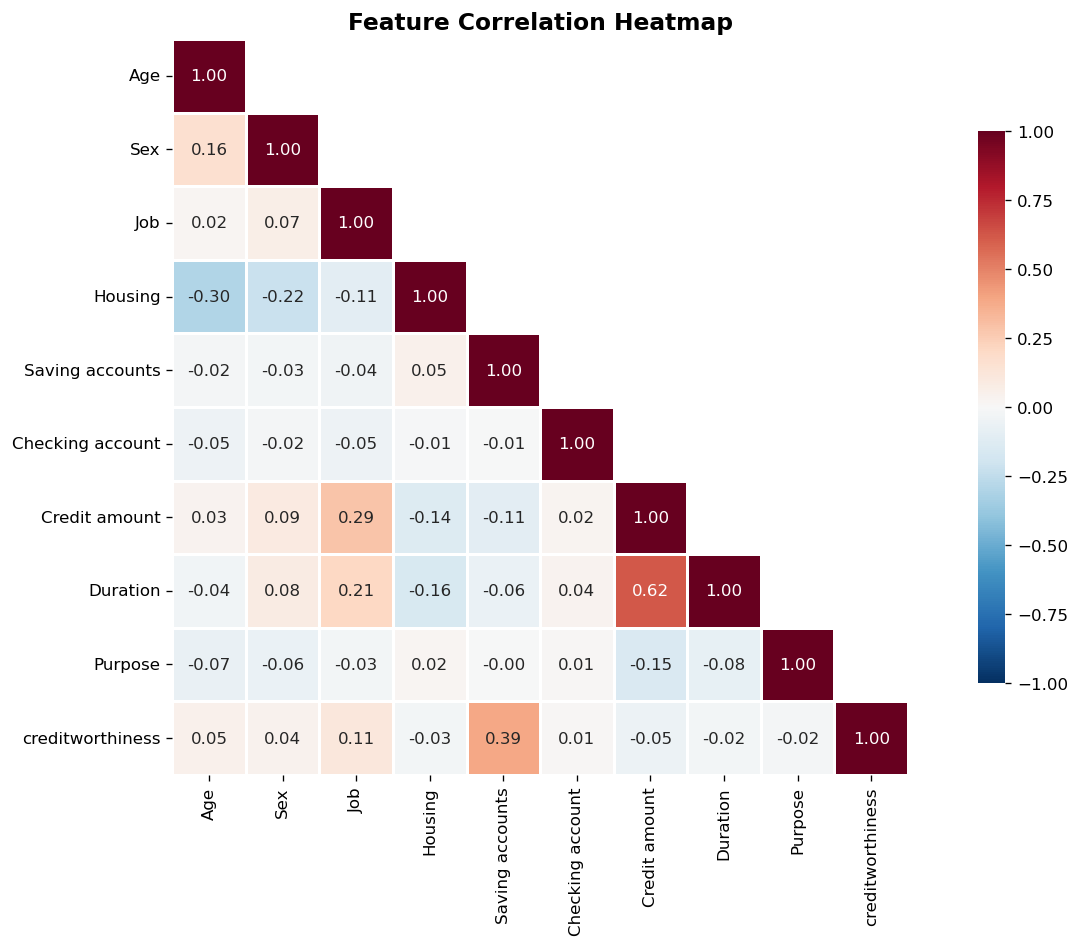


--- Top Features Correlated with Creditworthiness ---
  Saving accounts          : +0.3895  (Positive)
  Job                      : +0.1103  (Positive)
  Age                      : +0.0485  (Positive)
  Sex                      : +0.0434  (Positive)
  Checking account         : +0.0105  (Positive)
  Purpose                  : -0.0220  (Negative)
  Duration                 : -0.0246  (Negative)
  Housing                  : -0.0298  (Negative)
  Credit amount            : -0.0548  (Negative)


In [10]:
# Figure 4: Correlation Heatmap
# Encode categoricals numerically for correlation analysis
df_encoded = df.copy()
for col in ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']:
    df_encoded[col] = df_encoded[col].fillna('NA').astype('category').cat.codes

fig, ax = plt.subplots(figsize=(12, 8))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.8, cbar_kws={'shrink': 0.75},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations with target
print("\n--- Top Features Correlated with Creditworthiness ---")
target_corr = corr['creditworthiness'].sort_values(ascending=False)
for feat, val in target_corr.items():
    if feat != 'creditworthiness':
        direction = "Positive" if val > 0 else "Negative"
        print(f"  {feat:25s}: {val:+.4f}  ({direction})")

In [11]:
def transform_features(data):
    """
    Transform raw German Credit features into model-ready format.
    Handles: NaN filling, one-hot encoding, log transforms, derived features.
    Works on both full DataFrames (training) and single rows (prediction).
    """
    df = data.copy()

    # Drop index column if present
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

    # Handle missing values
    df['Saving accounts'] = df['Saving accounts'].fillna('no_information')
    df['Checking account'] = df['Checking account'].fillna('no_information')

    # One-hot encode categorical variables
    cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False, prefix=cat_cols)
    df = df.astype(int)

    # Convert boolean columns to int
    for col in df.select_dtypes(include=['bool']).columns:
        df[col] = df[col].astype(int)

    # Feature engineering - log transforms for skewed numeric features
    df['log_credit_amount'] = np.log1p(df['Credit amount'])
    df['log_duration'] = np.log1p(df['Duration'])
    df['log_age'] = np.log1p(df['Age'])

    # Feature: average monthly payment (credit amount / duration)
    df['monthly_payment'] = df['Credit amount'] / (df['Duration'] + 1)

    # Feature: risk score based on credit amount relative to age
    df['amount_per_age'] = df['Credit amount'] / (df['Age'] + 1)

    # Drop original numeric columns (keep log-transformed + derived versions)
    df.drop(columns=['Credit amount', 'Duration', 'Age'], inplace=True, errors='ignore')

    return df


def preprocess_german_credit(df_raw):
    """
    Full preprocessing pipeline: transform features + re-attach target.
    Returns a DataFrame with features and target (if present in input).
    """
    data = df_raw.copy()

    # Separate target if it exists
    target = data.pop('creditworthiness') if 'creditworthiness' in data.columns else None

    # Transform features
    data = transform_features(data)

    if target is not None:
        data['creditworthiness'] = target.values if hasattr(target, 'values') else target

    return data


# Preprocess the data (includes target handling)
df_processed = preprocess_german_credit(df.copy())

print(f"Processed dataset shape: {df_processed.shape}")
print(f"\nFeature columns ({df_processed.shape[1] - 1} features + target):")
print(list(df_processed.columns))
df_processed.head()

Processed dataset shape: (1000, 29)

Feature columns (28 features + target):
['Job', 'Sex_female', 'Sex_male', 'Housing_free', 'Housing_own', 'Housing_rent', 'Saving accounts_little', 'Saving accounts_moderate', 'Saving accounts_no_information', 'Saving accounts_quite rich', 'Saving accounts_rich', 'Checking account_little', 'Checking account_moderate', 'Checking account_no_information', 'Checking account_rich', 'Purpose_business', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others', 'log_credit_amount', 'log_duration', 'log_age', 'monthly_payment', 'amount_per_age', 'creditworthiness']


,Job,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_no_information,Saving accounts_quite rich,...,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,log_credit_amount,log_duration,log_age,monthly_payment,amount_per_age,creditworthiness
0,2,0,1,0,1,0,0,0,1,0,...,0,1,0,0,7.064759,1.945910,4.219508,167.000000,17.191176,0
1,2,1,0,0,1,0,1,0,0,0,...,0,1,0,0,8.691483,3.891820,3.135494,121.448980,258.739130,0
2,1,0,1,0,1,0,1,0,0,0,...,0,0,0,0,7.648263,2.564949,3.912023,161.230769,41.920000,0
3,2,0,1,1,0,0,1,0,0,0,...,1,0,0,0,8.972464,3.761200,3.828641,183.302326,171.347826,0
4,2,0,1,1,0,0,1,0,0,0,...,0,0,0,0,8.491055,3.218876,3.988984,194.800000,90.185185,0


In [12]:
# Prepare features and target
feature_cols = [c for c in df_processed.columns if c != 'creditworthiness']
X = df_processed[feature_cols].copy()
y = df_processed['creditworthiness'].copy()

# Train-Test Split (80-20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

# Feature Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Data prepared and scaled (standardized) successfully!")

Train set: 800 samples
Test set:  200 samples
Data prepared and scaled (standardized) successfully!


In [24]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, min_samples_split=15, min_samples_leaf=8,
        random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=15,
        min_samples_leaf=8, random_state=42, class_weight='balanced',
        n_jobs=-1
    ),
}

# Train and collect results
results = {}
trained_models = {}
all_roc_data = {}

for name, model in models.items():
    print()
    print(f"Training: {name}")
    print()

    # Use scaled data for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_scaled_df, y_train)
        y_pred = model.predict(X_test_scaled_df)
        y_proba = model.predict_proba(X_test_scaled_df)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if name == 'Logistic Regression':
        cv_scores = cross_val_score(model, X_train_scaled_df, y_train, cv=cv, scoring='roc_auc')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

    results[name] = {
        'Accuracy': accuracy, 'Precision': precision,
        'Recall': recall, 'F1-Score': f1, 'ROC-AUC': roc_auc,
        'CV Mean AUC': cv_scores.mean(),
        'CV Std AUC': cv_scores.std(),
    }

    # Print classification report
    print(classification_report(y_test, y_pred, target_names=['Bad', 'Good'], digits=4))
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"CV AUC:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    # Store ROC curve data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    all_roc_data[name] = (fpr, tpr, roc_auc)

results_df = pd.DataFrame(results).T


Training: Logistic Regression

              precision    recall  f1-score   support

         Bad     0.9733    0.8066    0.8822       181
        Good     0.3000    0.7895    0.4348        19

    accuracy                         0.8050       200
   macro avg     0.6367    0.7981    0.6585       200
weighted avg     0.9094    0.8050    0.8397       200

Accuracy:  0.8050
ROC-AUC:   0.8854
CV AUC:    0.9040 (+/- 0.0147)

Training: Decision Tree

              precision    recall  f1-score   support

         Bad     0.9793    0.7845    0.8712       181
        Good     0.2909    0.8421    0.4324        19

    accuracy                         0.7900       200
   macro avg     0.6351    0.8133    0.6518       200
weighted avg     0.9139    0.7900    0.8295       200

Accuracy:  0.7900
ROC-AUC:   0.8731
CV AUC:    0.8232 (+/- 0.0257)

Training: Random Forest

              precision    recall  f1-score   support

         Bad     0.9753    0.8729    0.9213       181
        Good     0.

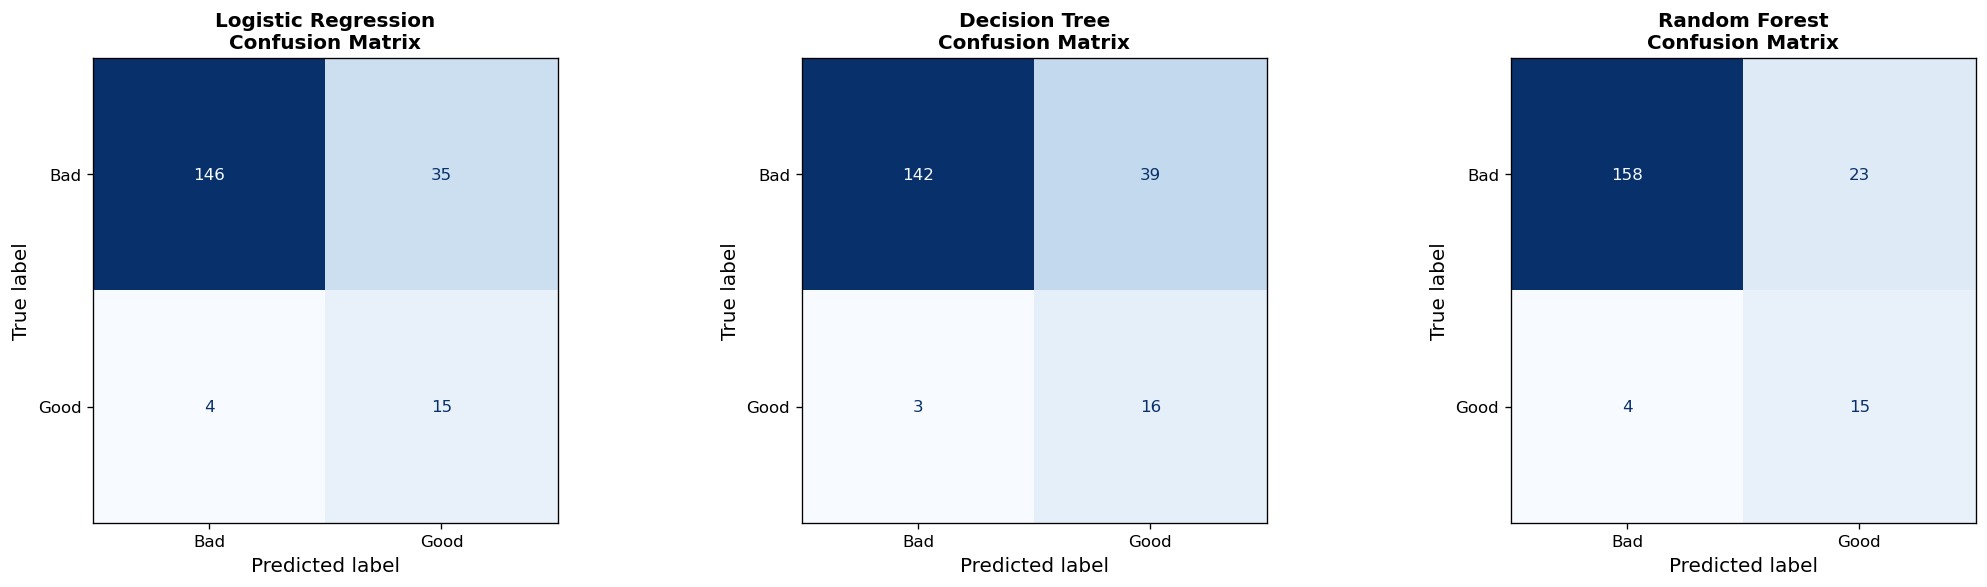

In [14]:
# Confusion Matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled_df)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bad', 'Good'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

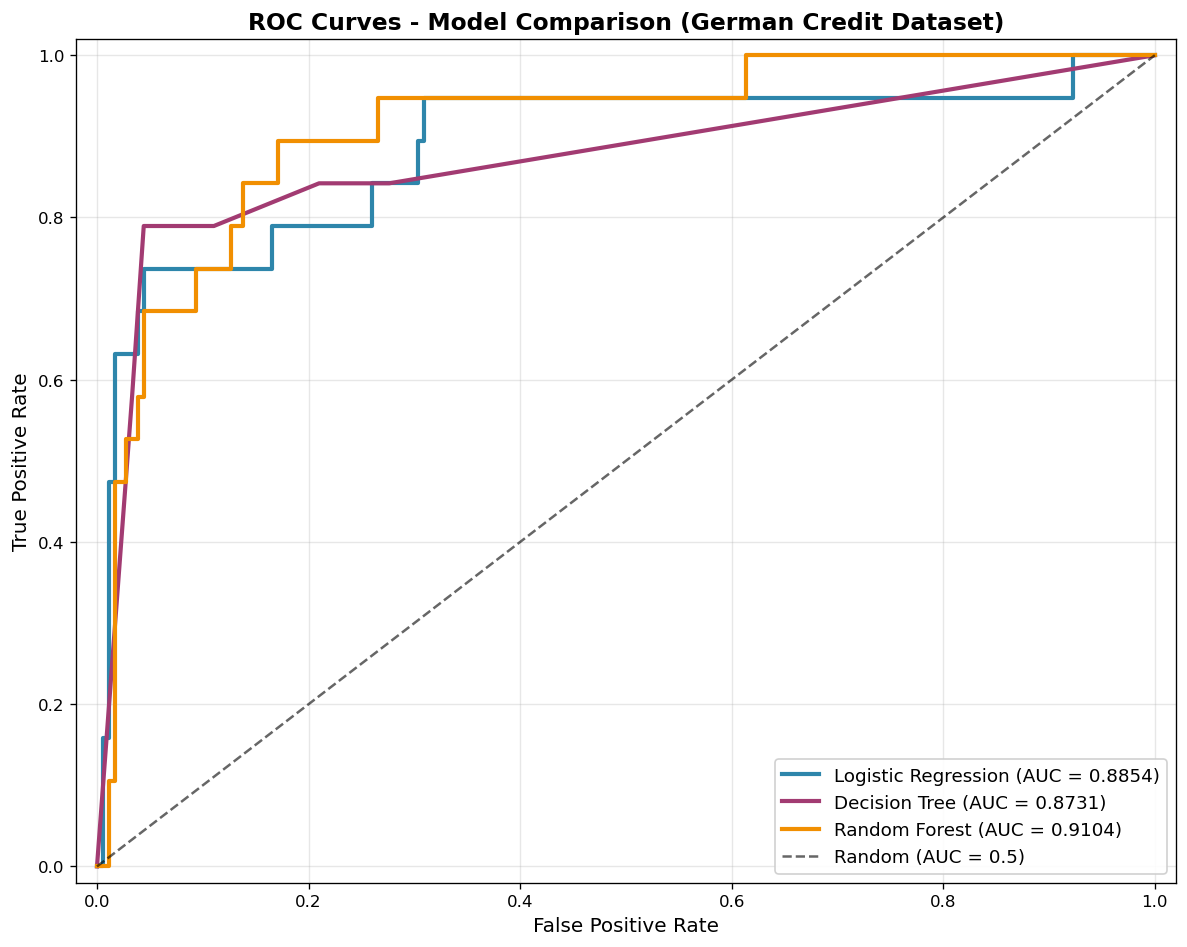

In [15]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for idx, (name, (fpr, tpr, roc_auc)) in enumerate(all_roc_data.items()):
    ax.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})',
            color=COLORS[idx % len(COLORS)])

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison (German Credit Dataset)', fontweight='bold', fontsize=14)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

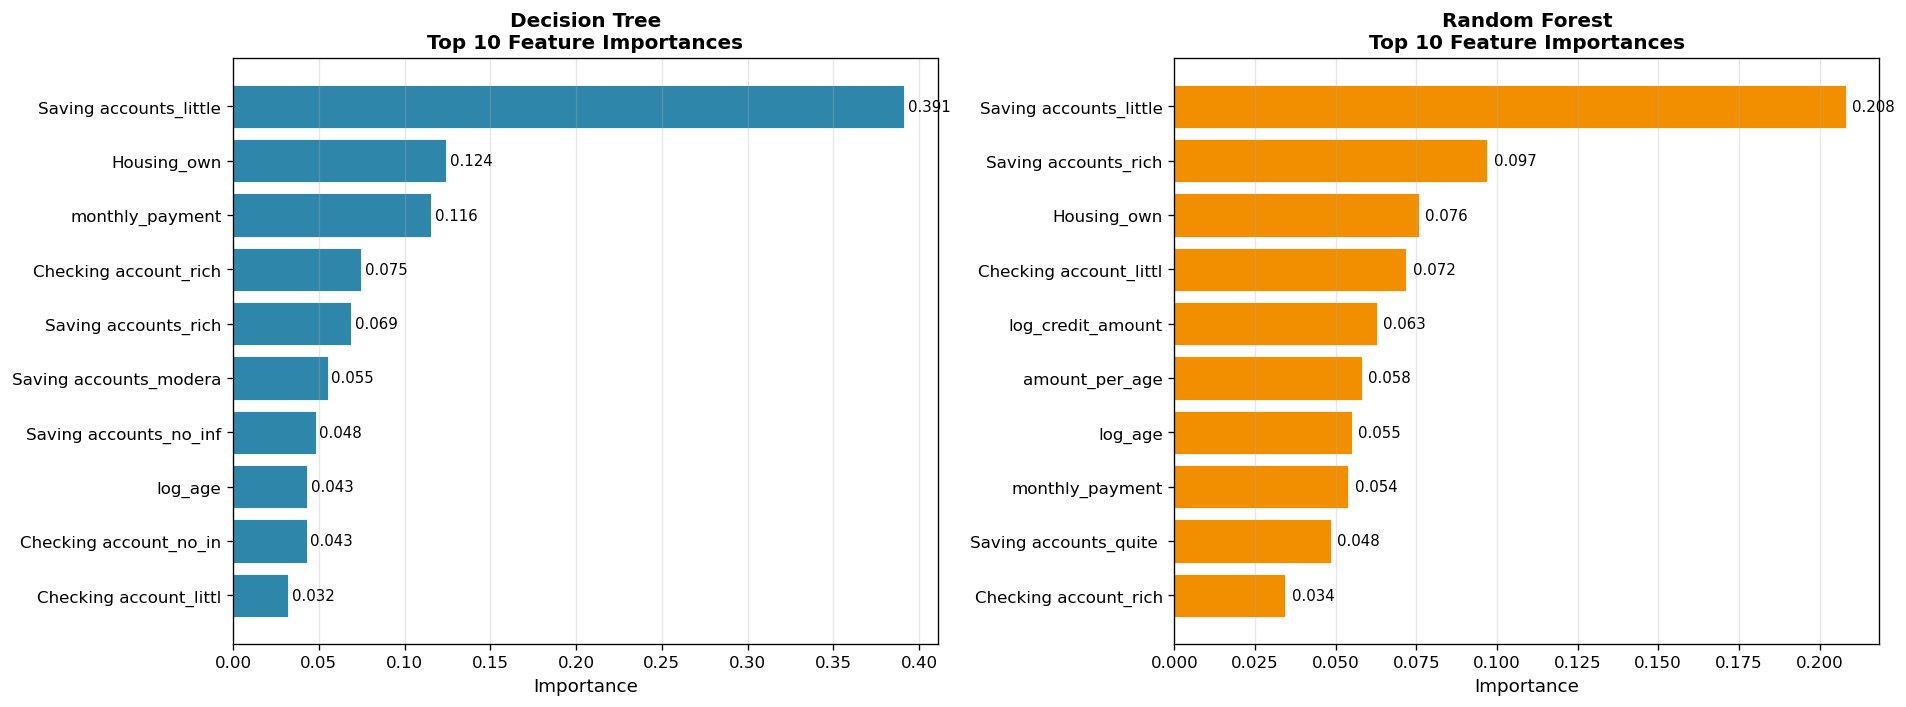

In [16]:
# Feature Importance (Tree-based models)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, model_name in enumerate(['Decision Tree', 'Random Forest']):
    if model_name not in trained_models:
        continue
    model = trained_models[model_name]
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]

    ax = axes[idx]
    feature_labels = [feature_cols[i][:22] for i in indices][::-1]
    bars = ax.barh(feature_labels, importances[indices][::-1],
                   color=COLORS[idx * 2], edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'{model_name}\nTop 10 Feature Importances', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')

    for bar, val in zip(bars, importances[indices][::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

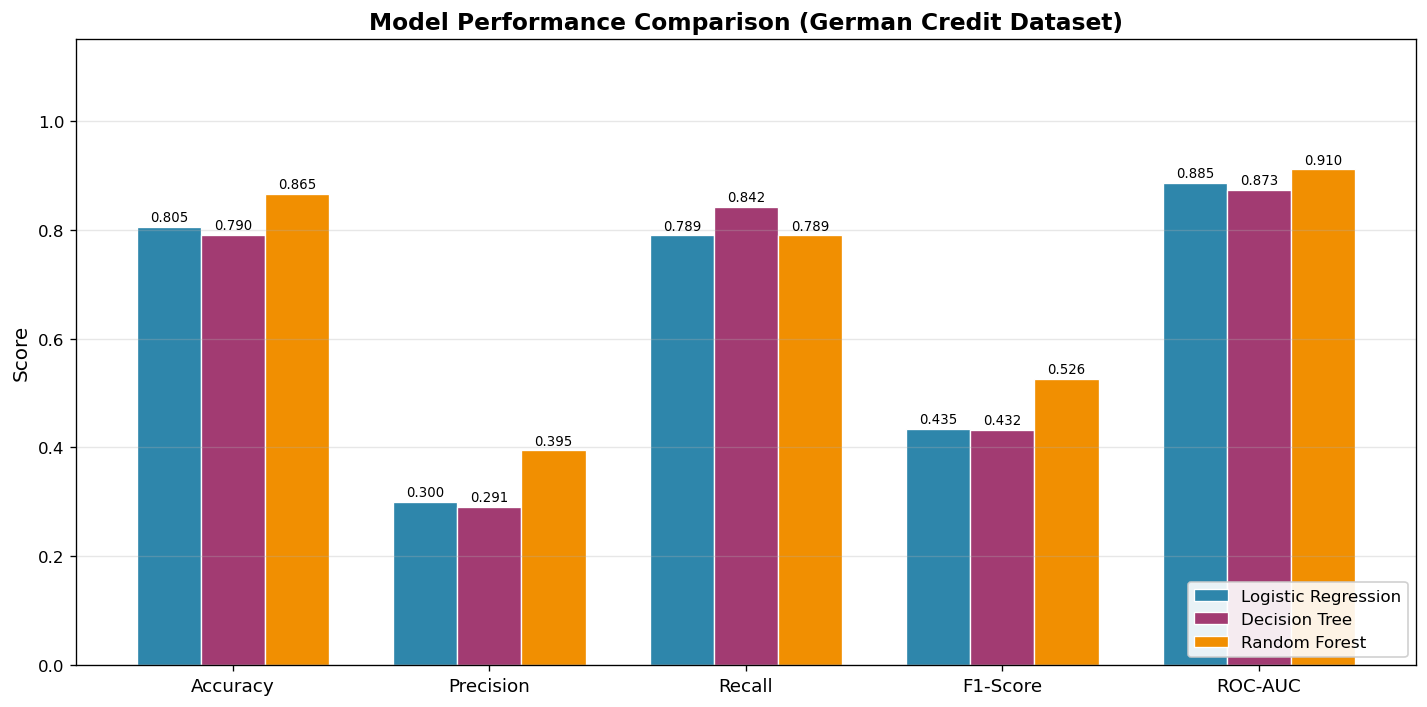

In [17]:
# Performance Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25
multiplier = 0

for idx, (name, row) in enumerate(results_df.iterrows()):
    offset = width * multiplier
    values = [row[m] for m in metrics_to_plot]
    bars = ax.bar(x + offset, values, width, label=name,
                  color=COLORS[idx % len(COLORS)], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, rotation=0)
    multiplier += 1

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison (German Credit Dataset)', fontweight='bold', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_ylim(0, 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [18]:
# Final Results Table
print("\n", results_df.round(4).to_string())
print()
print(f"Best Model by ROC-AUC: {results_df['ROC-AUC'].idxmax()}")
print(f"Best Model by F1-Score: {results_df['F1-Score'].idxmax()}")
print(f"Best Model by Accuracy: {results_df['Accuracy'].idxmax()}")


                      Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Mean AUC  CV Std AUC
Logistic Regression     0.805     0.3000  0.7895    0.4348   0.8854       0.9040      0.0147
Decision Tree           0.790     0.2909  0.8421    0.4324   0.8731       0.8232      0.0257
Random Forest           0.865     0.3947  0.7895    0.5263   0.9104       0.8988      0.0131

Best Model by ROC-AUC: Random Forest
Best Model by F1-Score: Random Forest
Best Model by Accuracy: Random Forest


In [25]:
def predict_new_applicant(models, scaler, feature_cols, applicant_data):
    """Predict creditworthiness for a new loan applicant using trained models."""
    # Convert dict to DataFrame
    app = pd.DataFrame([applicant_data])

    # Apply ONLY feature transformations (no target handling needed)
    app = transform_features(app)

    # Ensure all feature columns from training are present (handle missing one-hot cols)
    for col in feature_cols:
        if col not in app.columns:
            app[col] = 0  # Default for categories not in this applicant's data

    # Keep only training features, drop extras (from extra categories not in training)
    app = app[[c for c in app.columns if c in feature_cols]]

    # Reorder columns to match training order (ensures correct model input)
    app = app[feature_cols]

    # Display applicant profile
    print(f"\nApplicant Profile:")
    for key, val in applicant_data.items():
        print(f"  {key:25s}: {val}")

    print(f"\n{'─'*50}")
    print("Predictions:")
    print(f"{'─'*50}")

    probs = []
    for name, model in models.items():
        if name == 'Logistic Regression':
            app_scaled = scaler.transform(app)
            prob = model.predict_proba(app_scaled)[0, 1]
            pred = model.predict(app_scaled)[0]
        else:
            prob = model.predict_proba(app)[0, 1]
            pred = model.predict(app)[0]

        status = "[GOOD]" if pred == 1 else "[BAD]"
        confidence = prob if pred == 1 else 1 - prob
        print(f"  {name:25s}: {status}  (confidence: {confidence:.2%})")
        probs.append(prob)

    avg_prob = np.mean(probs)
    verdict = "[APPROVED]" if avg_prob >= 0.5 else "[DECLINED]"
    print(f"\n  {'─'*50}")
    print(f"  ENSEMBLE: Avg probability = {avg_prob:.2%}")
    print(f"  FINAL DECISION: {verdict}")
    return avg_prob

In [26]:
# Applicant 1: Low Risk - High earner, owns home, good savings
applicant_1 = {
    'Age': 45, 'Sex': 'male', 'Job': 3, 'Housing': 'own',
    'Saving accounts': 'rich', 'Checking account': 'rich',
    'Credit amount': 2000, 'Duration': 12, 'Purpose': 'car'
}
print("APPLICANT 1: LOW RISK")
prob1 = predict_new_applicant(trained_models, scaler, feature_cols, applicant_1)

APPLICANT 1: LOW RISK

Applicant Profile:
  Age                      : 45
  Sex                      : male
  Job                      : 3
  Housing                  : own
  Saving accounts          : rich
  Checking account         : rich
  Credit amount            : 2000
  Duration                 : 12
  Purpose                  : car

──────────────────────────────────────────────────
Predictions:
──────────────────────────────────────────────────
  Logistic Regression      : [GOOD]  (confidence: 99.99%)
  Decision Tree            : [GOOD]  (confidence: 95.73%)
  Random Forest            : [GOOD]  (confidence: 85.22%)

  ──────────────────────────────────────────────────
  ENSEMBLE: Avg probability = 93.65%
  FINAL DECISION: [APPROVED]


In [27]:
# Applicant 2: High Risk - Low earner, rents, no savings, high loan
applicant_2 = {
    'Age': 24, 'Sex': 'female', 'Job': 0, 'Housing': 'rent',
    'Saving accounts': 'little', 'Checking account': 'little',
    'Credit amount': 15000, 'Duration': 48, 'Purpose': 'business'
}
print("APPLICANT 2: HIGH RISK")
prob2 = predict_new_applicant(trained_models, scaler, feature_cols, applicant_2)

APPLICANT 2: HIGH RISK

Applicant Profile:
  Age                      : 24
  Sex                      : female
  Job                      : 0
  Housing                  : rent
  Saving accounts          : little
  Checking account         : little
  Credit amount            : 15000
  Duration                 : 48
  Purpose                  : business

──────────────────────────────────────────────────
Predictions:
──────────────────────────────────────────────────
  Logistic Regression      : [BAD]  (confidence: 100.00%)
  Decision Tree            : [BAD]  (confidence: 100.00%)
  Random Forest            : [BAD]  (confidence: 95.19%)

  ──────────────────────────────────────────────────
  ENSEMBLE: Avg probability = 1.60%
  FINAL DECISION: [DECLINED]


In [28]:
# Applicant 3: Medium Risk - Average profile
applicant_3 = {
    'Age': 35, 'Sex': 'male', 'Job': 2, 'Housing': 'own',
    'Saving accounts': 'moderate', 'Checking account': 'moderate',
    'Credit amount': 5000, 'Duration': 24, 'Purpose': 'radio/TV'
}
print("APPLICANT 3: MEDIUM RISK")
prob3 = predict_new_applicant(trained_models, scaler, feature_cols, applicant_3)

APPLICANT 3: MEDIUM RISK

Applicant Profile:
  Age                      : 35
  Sex                      : male
  Job                      : 2
  Housing                  : own
  Saving accounts          : moderate
  Checking account         : moderate
  Credit amount            : 5000
  Duration                 : 24
  Purpose                  : radio/TV

──────────────────────────────────────────────────
Predictions:
──────────────────────────────────────────────────
  Logistic Regression      : [BAD]  (confidence: 73.40%)
  Decision Tree            : [BAD]  (confidence: 100.00%)
  Random Forest            : [BAD]  (confidence: 60.64%)

  ──────────────────────────────────────────────────
  ENSEMBLE: Avg probability = 21.99%
  FINAL DECISION: [DECLINED]
